## Sign Condition Classifier
#### EfficientNet-B2

*Daniela Curmi, 0058805L*

In [1]:
# All libraries used for this notebook have been included below
import json
from pathlib import Path
from typing import List, Tuple
import torch
import torch.nn as nn
from torchvision.models import efficientnet_b2, EfficientNet_B2_Weights
from torch.utils.data import Dataset, DataLoader
from PIL import Image
from torchvision import transforms
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, precision_score, recall_score, f1_score
import numpy as np
import matplotlib.pyplot as plt
import random
import pandas as pd

device = "cuda" if torch.cuda.is_available() else "cpu"
print(device)

cuda


### Prepare COCO-based_COCO_condition Dataset structure

In [ ]:
ROOT = Path("Individual Results/EfficientNetB2/COCO-based_COCO_condition")
ANN_DIR = ROOT / "annotations"
SPLITS = ["train", "val", "test"]

for split in SPLITS:
    src_json = ANN_DIR / f"{split}.json"
    dst_dir = ROOT / split
    dst_dir.mkdir(parents=True, exist_ok=True)
    dst_json = dst_dir / "_annotations.coco.json"

    with src_json.open("r", encoding="utf-8") as f:
        data = json.load(f)

    coco_out = {
        "info": data.get("info", {}),
        "licenses": data.get("licenses", []),
        "images": [],
        "annotations": [],
        "categories": []
    }

    # Images
    for img in data["images"]:
        coco_out["images"].append({
            "id": img["id"],
            "file_name": img["file_name"],
            "width": img["width"],
            "height": img["height"]
        })

    # Categories 
    for cat in data["categories"]:
        coco_out["categories"].append({
            "id": cat["id"],
            "name": cat["name"],
            "supercategory": "condition"
        })

    # Annotations
    for ann in data["annotations"]:
        coco_out["annotations"].append({
            "id": ann["id"],
            "image_id": ann["image_id"],
            "category_id": ann["category_id"],
            "bbox": ann["bbox"],  # x, y, w, h
            "area": ann.get("area", ann["bbox"][2] * ann["bbox"][3]),
            "iscrowd": ann.get("iscrowd", 0)
        })

    # Write output
    with dst_json.open("w", encoding="utf-8") as f:
        json.dump(coco_out, f, indent=2)

    print(f"[OK] Wrote {dst_json}")

[OK] Wrote COCO-based_COCO_condition\train\_annotations.coco.json
[OK] Wrote COCO-based_COCO_condition\val\_annotations.coco.json
[OK] Wrote COCO-based_COCO_condition\test\_annotations.coco.json


### Crop COCO Dataset Method

In [6]:
class CocoCropDataset(Dataset):
    def __init__(self, ann_path: Path, img_dir: Path, transform=None):
        self.img_dir = img_dir
        self.transform = transform

        with ann_path.open("r", encoding="utf-8") as f:
            coco = json.load(f)

        self.images = {im["id"]: im for im in coco["images"]}
        self.annotations = coco["annotations"]

        # Sort categories by ID for deterministic class order
        categories = sorted(coco["categories"], key=lambda c: c["id"])
        self.class_names = [c["name"] for c in categories]
        self.cat_id_to_idx = {c["id"]: i for i, c in enumerate(categories)}

        self.samples: List[Tuple[Path, Tuple[float, float, float, float], int]] = []

        for ann in self.annotations:
            img_info = self.images[ann["image_id"]]
            img_path = img_dir / Path(img_info["file_name"]).name
            if not img_path.exists():
                continue

            bbox = ann["bbox"]  # x, y, w, h
            cls = self.cat_id_to_idx[ann["category_id"]]

            self.samples.append((img_path, bbox, cls))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        img_path, bbox, cls = self.samples[idx]
        img = Image.open(img_path).convert("RGB")

        x, y, w, h = bbox

        # Convert to integer pixel coords
        x1 = int(round(x))
        y1 = int(round(y))
        x2 = int(round(x + w))
        y2 = int(round(y + h))

        # Clip to image boundaries
        x1 = max(0, min(x1, img.width - 1))
        y1 = max(0, min(y1, img.height - 1))
        x2 = max(0, min(x2, img.width))
        y2 = max(0, min(y2, img.height))

        if x2 <= x1 or y2 <= y1:
            # Skip invalid crop by returning a minimal fallback
            return self.__getitem__((idx + 1) % len(self))
        else:
            crop = img.crop((x1, y1, x2, y2))

        if self.transform:
            crop = self.transform(crop)

        return crop, cls

### Apply Transforms, Crop and Load Datasets

In [ ]:
train_transform = transforms.Compose([
    transforms.Resize((260, 260)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    ),
])

val_transform = transforms.Compose([
    transforms.Resize((260, 260)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    ),
])

train_dataset = CocoCropDataset(
    ann_path=Path("Individual Results/EfficientNetB2/COCO-based_COCO_condition/train/_annotations.coco.json"),
    img_dir=Path("Individual Results/EfficientNetB2/COCO-based_COCO_condition/train"),
    transform=train_transform
)

val_dataset = CocoCropDataset(
    ann_path=Path("Individual Results/EfficientNetB2/COCO-based_COCO_condition/val/_annotations.coco.json"),
    img_dir=Path("Individual Results/EfficientNetB2/COCO-based_COCO_condition/val"), 
    transform=val_transform
)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=0, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False, num_workers=0, pin_memory=True)

### Define EfficientNet-B2 Model

In [4]:
class EfficientNetB2(nn.Module):
    def __init__(self, num_classes=3):
        super().__init__()
        weights = EfficientNet_B2_Weights.DEFAULT 
        self.backbone = efficientnet_b2(weights=weights)
        in_features = self.backbone.classifier[1].in_features
        self.backbone.classifier[1] = nn.Linear(in_features, num_classes)

    def forward(self, x):
        return self.backbone(x)

model = EfficientNetB2(num_classes=3).to(device)

### EfficientNet-B2 Classifier Training loop

In [21]:
def train_one_epoch(model, loader, optimizer, criterion):
    model.train()
    running_loss = 0
    correct = 0
    total = 0

    for imgs, labels in loader:
        imgs = imgs.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = model(imgs)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item() * imgs.size(0)
        preds = outputs.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    return running_loss / total, correct / total

@torch.no_grad()
def validate(model, loader, criterion):
    model.eval()
    running_loss = 0
    correct = 0
    total = 0

    for imgs, labels in loader:
        imgs = imgs.to(device)
        labels = labels.to(device)

        outputs = model(imgs)
        loss = criterion(outputs, labels)

        running_loss += loss.item() * imgs.size(0)
        preds = outputs.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    return running_loss / total, correct / total


In [ ]:
for param in model.parameters():
    param.requires_grad = True

best_val_loss = float("inf")
patience = 3
counter = 0
num_epochs = 10

train_acc_history = []
val_acc_history = []

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=3e-4, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=num_epochs)

for epoch in range(num_epochs):
    train_loss, train_acc = train_one_epoch(model, train_loader, optimizer, criterion)
    val_loss, val_acc = validate(model, val_loader, criterion)

    train_acc_history.append(train_acc)
    val_acc_history.append(val_acc)

    scheduler.step()

    print(
        f"[Epoch {epoch+1:02d}] "
        f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.3f} | "
        f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.3f}"
    )

    # Early stopping
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        counter = 0

        torch.save(
            {
                "model": model.state_dict(),
                "epoch": epoch,
                "val_loss": val_loss,
                "val_acc": val_acc,
            },
            "efficientnet_b2.pth"
        )
    else:
        counter += 1
        if counter >= patience:
            print(f"Early stopping at epoch {epoch}, with patience {patience}")
            break


[P1 Epoch 01] Train Loss: 0.8603 | Train Acc: 0.608 | Val Loss: 0.7523 | Val Acc: 0.681
[P1 Epoch 02] Train Loss: 0.4892 | Train Acc: 0.820 | Val Loss: 0.6545 | Val Acc: 0.698
[P1 Epoch 03] Train Loss: 0.2597 | Train Acc: 0.925 | Val Loss: 0.6120 | Val Acc: 0.716
[P1 Epoch 04] Train Loss: 0.1388 | Train Acc: 0.972 | Val Loss: 0.7228 | Val Acc: 0.681
[P1 Epoch 05] Train Loss: 0.0935 | Train Acc: 0.985 | Val Loss: 0.6732 | Val Acc: 0.716
[P1 Epoch 06] Train Loss: 0.0682 | Train Acc: 0.991 | Val Loss: 0.6686 | Val Acc: 0.716
Early stopping in phase P1


In [ ]:
test_dataset = CocoCropDataset(
    ann_path=Path("Individual Results/EfficientNetB2/COCO-based_COCO_condition/test/_annotations.coco.json"),
    img_dir=Path("Individual Results/EfficientNetB2/COCO-based_COCO_condition/test"),
    transform=val_transform
)

test_loader = DataLoader(
    test_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=0
)

#### Individual Evaluation

In [ ]:
# Values from training are stored here for the purpose of reproducability
train_acc_history = [0.608, 0.820, 0.925, 0.972, 0.985, 0.991]
val_acc_history = [0.681, 0.698, 0.716, 0.681, 0.716, 0.716]

C:\Users\danie\AppData\Local\Temp\ipykernel_20184\4145460358.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load("efficientnet_b2.pth", map_location=

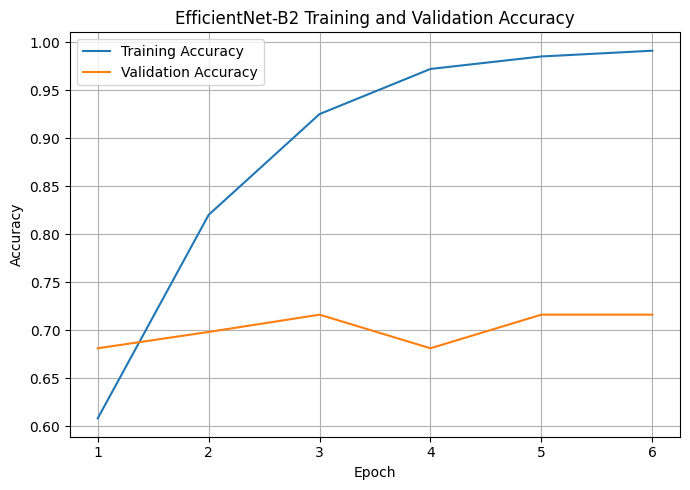

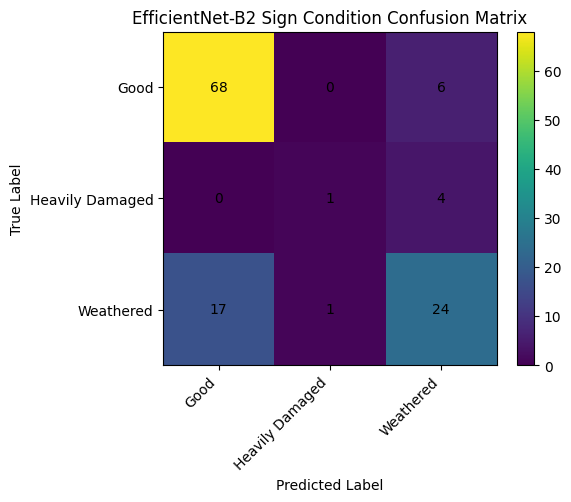

                 precision    recall  f1-score   support

           Good     0.8000    0.9189    0.8553        74
Heavily Damaged     0.5000    0.2000    0.2857         5
      Weathered     0.7059    0.5714    0.6316        42

       accuracy                         0.7686       121
      macro avg     0.6686    0.5634    0.5909       121
   weighted avg     0.7549    0.7686    0.7541       121



In [ ]:
checkpoint = torch.load("Models/efficientnet_b2.pth", map_location=device)
model.load_state_dict(checkpoint["model"])
model.eval()

# Train and Val Accuracy over total number of epochs
num_epochs = range(1, len(train_acc_history) + 1)

plt.figure(figsize=(7, 5))
plt.plot(num_epochs, train_acc_history, label="Training Accuracy")
plt.plot(num_epochs, val_acc_history, label="Validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("EfficientNet-B2 Training and Validation Accuracy")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

@torch.no_grad()
def collect_predictions(model, loader):
    all_preds = []
    all_labels = []

    for imgs, labels in loader:
        imgs = imgs.to(device)
        labels = labels.to(device)

        outputs = model(imgs)
        preds = outputs.argmax(dim=1)

        all_preds.append(preds.cpu().numpy())
        all_labels.append(labels.cpu().numpy())

    return np.concatenate(all_preds), np.concatenate(all_labels)

y_pred, y_true = collect_predictions(model, test_loader)

class_names = train_dataset.class_names  # ["Good", "Heavily Damaged", "Weathered"]

# Confusion matrix including number of signs 
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6, 5))
plt.imshow(cm, interpolation="nearest")
plt.title("EfficientNet-B2 Sign Condition Confusion Matrix")
plt.colorbar()

tick_marks = np.arange(len(class_names))
plt.xticks(tick_marks, class_names, rotation=45, ha="right")
plt.yticks(tick_marks, class_names)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")

thresh = cm.max() / 2.0
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(
            j, i, cm[i, j],
            ha="center", va="center"
        )

plt.tight_layout()
plt.show()

print(classification_report(y_true, y_pred, target_names=class_names, digits=4))


#### Group Evaluation

In [ ]:
# Compute metrics and print results
test_acc = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred, average='weighted', zero_division=0)
recall = recall_score(y_true, y_pred, average='weighted', zero_division=0)
f1 = f1_score(y_true, y_pred, average='weighted', zero_division=0)

metrics = {
    "Model Name": "EfficientNet-B2",
    "Accuracy": test_acc,
    "Precision": precision,
    "Recall": recall,
    "F1-score": f1
}

# Convert to DataFrame and save to CSV
df = pd.DataFrame([metrics])
df.to_csv("Group Results/Classifier/efficientnetb2.csv", index=False)

print("Model Name: EfficientNet-B2")
print("Test Accuracy: {:.4f}".format(test_acc))
print("Precision: {:.4f}".format(precision))
print("Recall: {:.4f}".format(recall))
print("F1-Score: {:.4f}".format(f1))

Model Name: EfficientNet-B2
Test Accuracy: 0.7686
Precision: 0.7549
Recall: 0.7686
F1-Score: 0.7541


### Sample Sign Condition Classification EfficientNet-B2

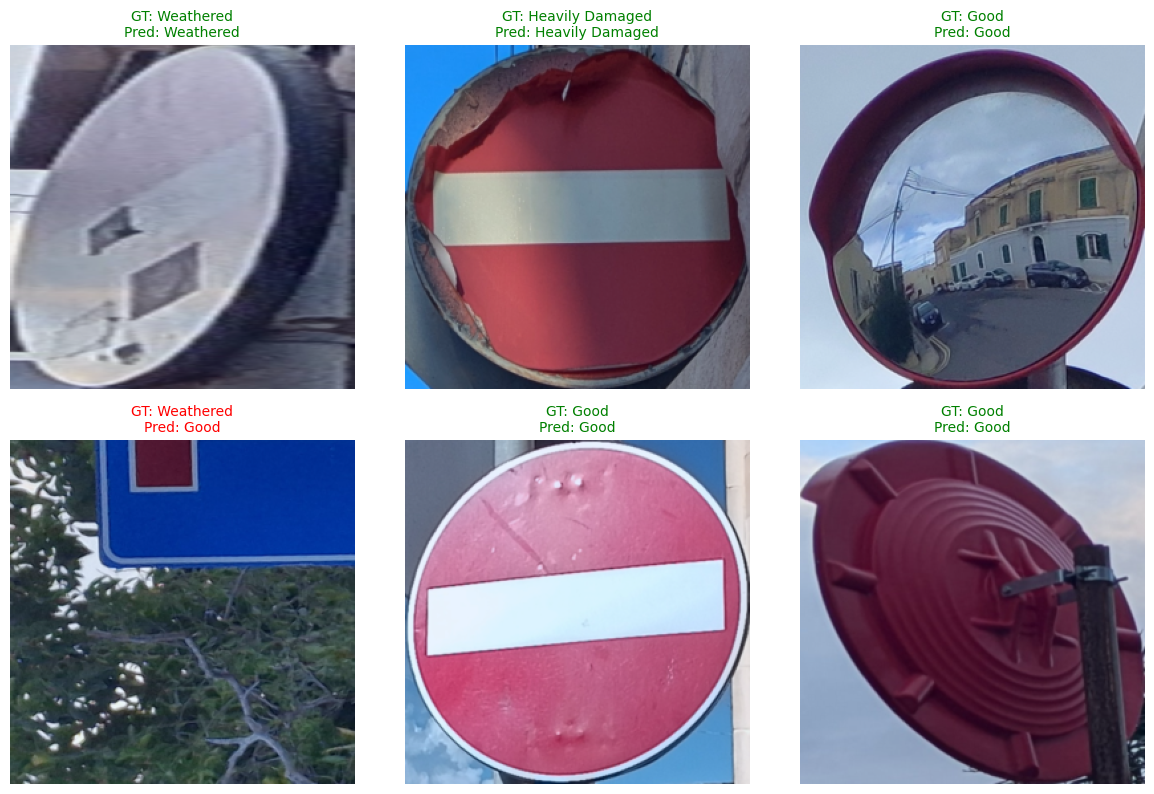

: 

In [ ]:
def show_sample_predictions(model, dataset, class_names, device, num_samples=6):
    indices = random.sample(range(len(dataset)), num_samples)

    plt.figure(figsize=(12, 12))

    for i, idx in enumerate(indices):
        image, label = dataset[idx]

        # Add batch dimension
        image_batch = image.unsqueeze(0).to(device)

        with torch.no_grad():
            output = model(image_batch)
            pred = output.argmax(dim=1).item()

        # Convert tensor to image for display
        img_np = image.permute(1, 2, 0).cpu().numpy()
        img_np = (img_np - img_np.min()) / (img_np.max() - img_np.min())

        gt_name = class_names[label]
        pred_name = class_names[pred]

        correct = (label == pred)
        title_color = "green" if correct else "red"

        plt.subplot(3, 3, i + 1)
        plt.imshow(img_np)
        plt.axis("off")
        plt.title(
            f"GT: {gt_name}\nPred: {pred_name}",
            color=title_color,
            fontsize=10
        )
    plt.tight_layout()
    plt.show()

show_sample_predictions(model=model, dataset=test_dataset, class_names=class_names, device=device, num_samples=6)